# Cardiovascular Disease Predictor Using Decision Tree


## Introduction
Cardiovascular disease is one of the leading causes of death worldwide. Risk factors include
age, high blood pressure, high cholesterol, and lifestyle habits like smoking.

## Import Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## Load Dataset


For Glucose and Cholesterol ====>   1: normal, 2: above normal, 3: well above normal

In [59]:
df = pd.read_csv("cardio_train.csv", sep=';')
df = df.drop(columns=['id'])
df = df.rename(columns={'age': 'age(in days)'})
df = df.rename(columns={'gender': 'Gender(1 : woman | 2 : Man)'})
df = df.rename(columns={'height': 'Height(in cm)'})
df = df.rename(columns={'weight': 'weight(in kg)'})
df = df.rename(columns={'ap_hi': 'sys_pressure'})
df = df.rename(columns={'ap_lo': 'dia_pressure'})
print("Shape:", df.shape)
df.head()

Shape: (70000, 12)


,age(in days),Gender(1 : woman | 2 : Man),Height(in cm),weight(in kg),sys_pressure,dia_pressure,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Missing value and duplicates


In [60]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age(in days)                 70000 non-null  int64  
 1   Gender(1 : woman | 2 : Man)  70000 non-null  int64  
 2   Height(in cm)                70000 non-null  int64  
 3   weight(in kg)                70000 non-null  float64
 4   sys_pressure                 70000 non-null  int64  
 5   dia_pressure                 70000 non-null  int64  
 6   cholesterol                  70000 non-null  int64  
 7   gluc                         70000 non-null  int64  
 8   smoke                        70000 non-null  int64  
 9   alco                         70000 non-null  int64  
 10  active                       70000 non-null  int64  
 11  cardio                       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB
None


In [61]:
print(df.describe())

       age(in days)  Gender(1 : woman | 2 : Man)  Height(in cm)  \
count  70000.000000                 70000.000000   70000.000000   
mean   19468.865814                     1.349571     164.359229   
std     2467.251667                     0.476838       8.210126   
min    10798.000000                     1.000000      55.000000   
25%    17664.000000                     1.000000     159.000000   
50%    19703.000000                     1.000000     165.000000   
75%    21327.000000                     2.000000     170.000000   
max    23713.000000                     2.000000     250.000000   

       weight(in kg)  sys_pressure  dia_pressure   cholesterol          gluc  \
count   70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean       74.205690    128.817286     96.630414      1.366871      1.226457   
std        14.395757    154.011419    188.472530      0.680250      0.572270   
min        10.000000   -150.000000    -70.000000      1.000000      1.000000

In [62]:
print("Missing values:\n", df.isnull().sum())

df[df.duplicated()]
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 age(in days)                   0
Gender(1 : woman | 2 : Man)    0
Height(in cm)                  0
weight(in kg)                  0
sys_pressure                   0
dia_pressure                   0
cholesterol                    0
gluc                           0
smoke                          0
alco                           0
active                         0
cardio                         0
dtype: int64

Duplicate rows: 24


In [63]:
df[['sys_pressure', 'dia_pressure']].describe().round(2)

,sys_pressure,dia_pressure
count,70000.00,70000.00
mean,128.82,96.63
std,154.01,188.47
min,-150.00,-70.00
25%,120.00,80.00
50%,120.00,80.00
75%,140.00,90.00
max,16020.00,11000.00


Blood pressure values have a minimum of negative values i.e. ERROR/ WRONG ENTRY

## Data Cleaning
Removing wrong readings 

In [64]:
df = df.drop_duplicates()

# converting age to in years 
df['age(in days)'] = (df['age(in days)'] / 365.25).astype(int) # years 

# bloodpressure readings
df = df[(df['sys_pressure'].between(70, 250)) & (df['dia_pressure'].between(40, 200))] 
df = df[df['sys_pressure'] > df['dia_pressure']]

# height and weight 
df = df[(df['Height(in cm)'].between(100, 220)) & (df['weight(in kg)'].between(30, 180))]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (68611, 12)


## Exploratory Data Analysis

### Target Distribution

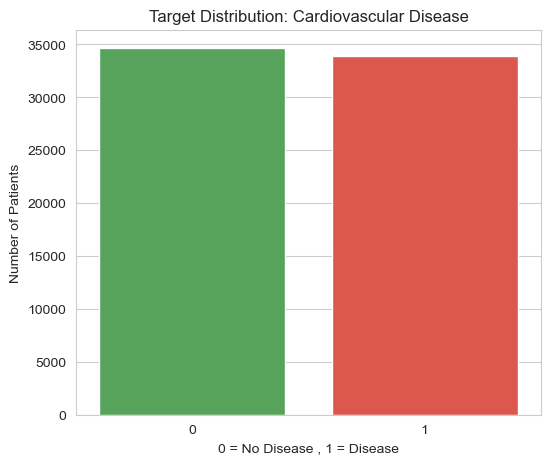

In [65]:
plt.figure(figsize=(6, 5))
sns.countplot(x='cardio', data=df, hue='cardio', palette=['#4CAF50', '#F44336'], legend=False)
plt.title('Target Distribution: Cardiovascular Disease')
plt.xlabel('0 = No Disease , 1 = Disease')
plt.ylabel('Number of Patients')
plt.show()

The target classes are close to balanced, which makes accuracy a fair evaluation metric here.

### Age Distribution

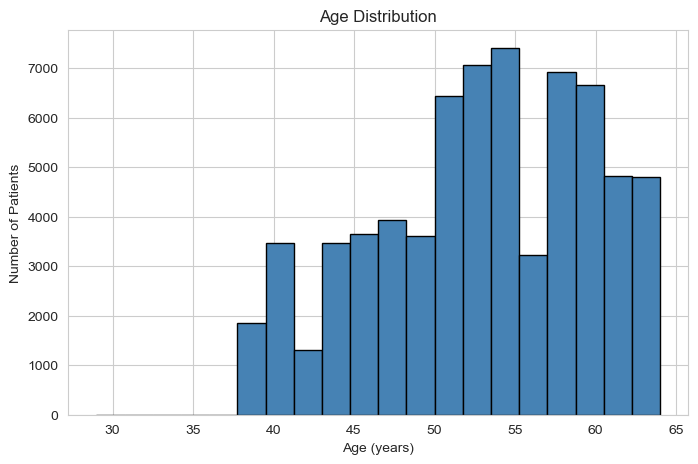

In [67]:
plt.figure(figsize=(8, 5))
plt.hist(df['age(in days)'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.show()

Patients range from about 30 to 65 years old, with most concentrated between 45 and 60.

### Cholesterol vs Disease

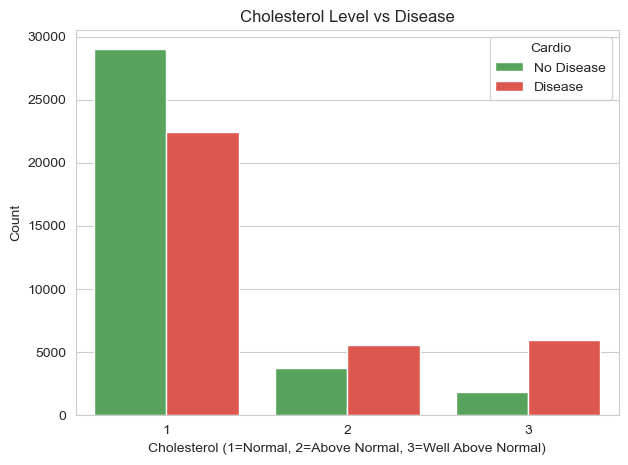

In [68]:
plt.figure(figsize=(7, 5))
sns.countplot(x='cholesterol', hue='cardio', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Cholesterol Level vs Disease')
plt.xlabel('Cholesterol (1=Normal, 2=Above Normal, 3=Well Above Normal)')
plt.ylabel('Count')
plt.legend(title='Cardio', labels=['No Disease', 'Disease'])
plt.show()

Patients with above-normal or well-above-normal cholesterol show a higher proportion of disease.

### Blood Pressure vs Disease

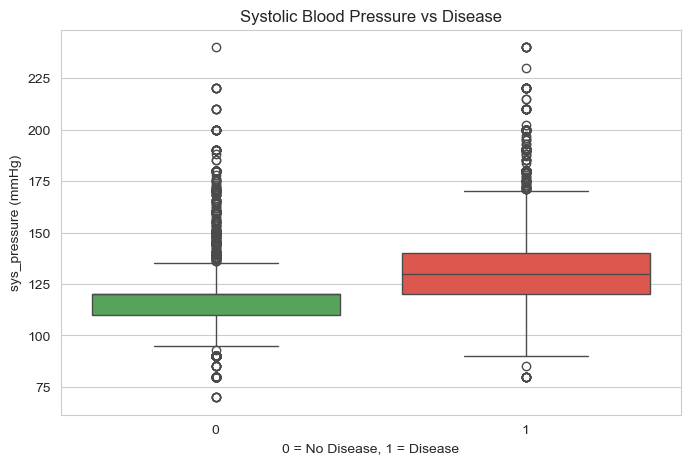

In [69]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='cardio', y='sys_pressure', data=df, hue='cardio', palette=['#4CAF50', '#F44336'], legend=False)
plt.title('Systolic Blood Pressure vs Disease')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('sys_pressure (mmHg)')
plt.show()

Patients with cardiovascular disease tend to have noticeably higher systolic blood pressure.

### Correlation Heatmap

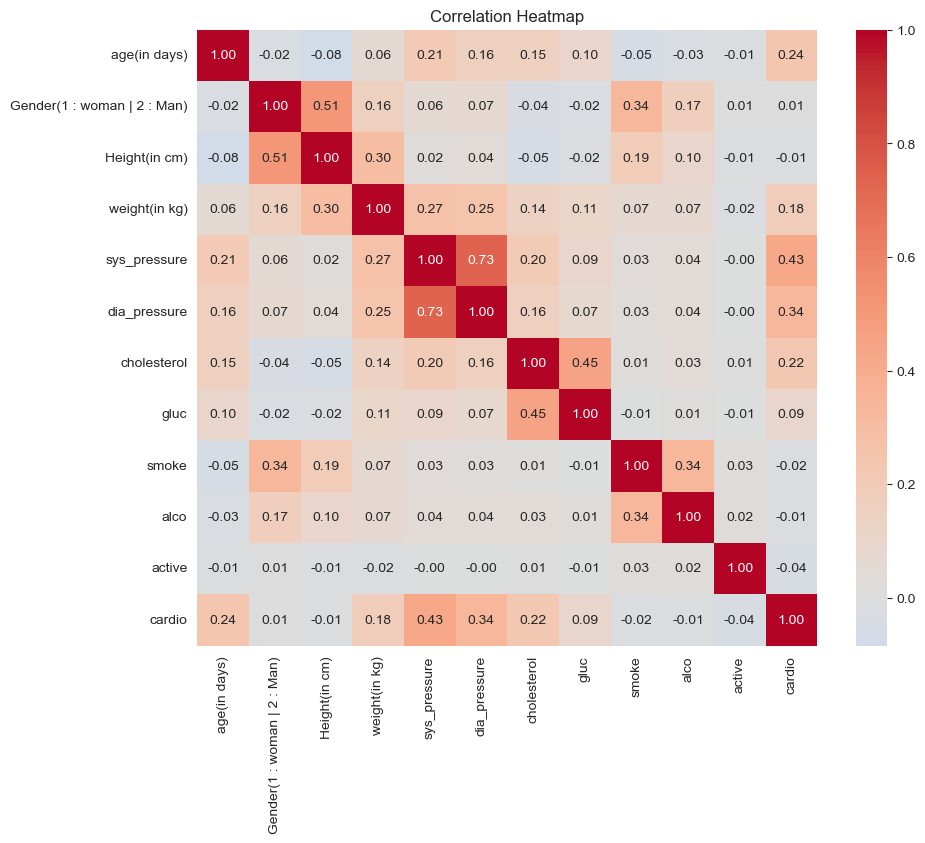

In [70]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

`sys_pressure`, `dia_pressure`, `age`, and `cholesterol` show the strongest positive correlation with
the target. Lifestyle factors like smoking and alcohol show very weak correlation in this
dataset.

### Disease by Age Group

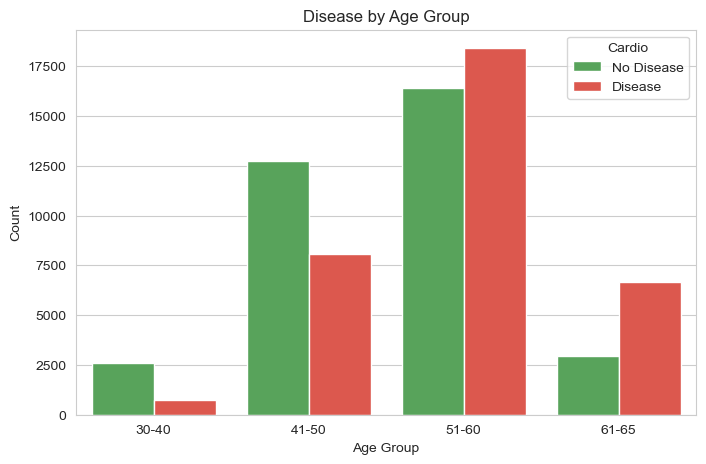

In [71]:
df['age_group'] = pd.cut(df['age(in days)'], bins=[29, 40, 50, 60, 65],
                labels=['30-40', '41-50', '51-60', '61-65'])

plt.figure(figsize=(8, 5))
sns.countplot(x='age_group', hue='cardio', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Disease by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Cardio', labels=['No Disease', 'Disease'])
plt.show()

df = df.drop(columns=['age_group'])

The proportion of patients with disease clearly increases in the older age groups.

## Feature Selection

All 11 cleaned features are used as input (`X`), and `cardio` is the target (`y`).

In [72]:
X = df.drop(columns=['cardio'])
y = df['cardio']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (68611, 11)
y shape: (68611,)


## Train-Test Split

We split the data 80/20.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

## Decision Tree Model

A Decision Tree splits the data using a sequence of yes/no questions on feature values.

- **Gini Impurity** measures how mixed a node is. A Gini of 0 means a node contains only one class.
- **max_depth=5** limits the tree to 5 levels, keeping it simple and reducing the risk of
  overfitting.

In [73]:
model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("Tree depth used:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())

Tree depth used: 5
Number of leaves: 32


## Evaluation

In [74]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 72.94%


In [75]:
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.71      0.80      0.75      6917
     Disease       0.76      0.66      0.71      6806

    accuracy                           0.73     13723
   macro avg       0.73      0.73      0.73     13723
weighted avg       0.73      0.73      0.73     13723



**Precision**: of patients predicted to have disease, how many actually did.

**Recall**: of patients who actually have disease, how many the model correctly caught.

**F1-score**: the balance between precision and recall.

In a medical context, recall on the disease class matters most — missing a real case is
more dangerous than a false alarm.

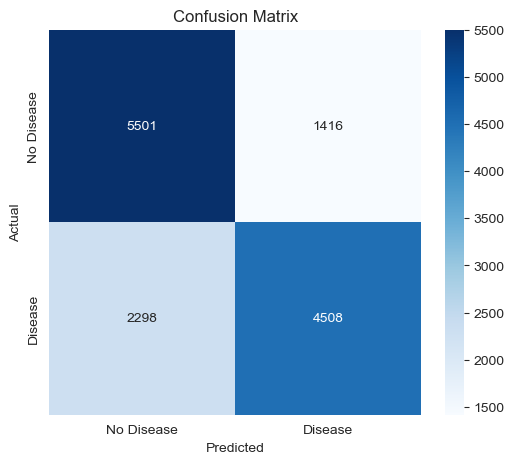

In [76]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature Importance

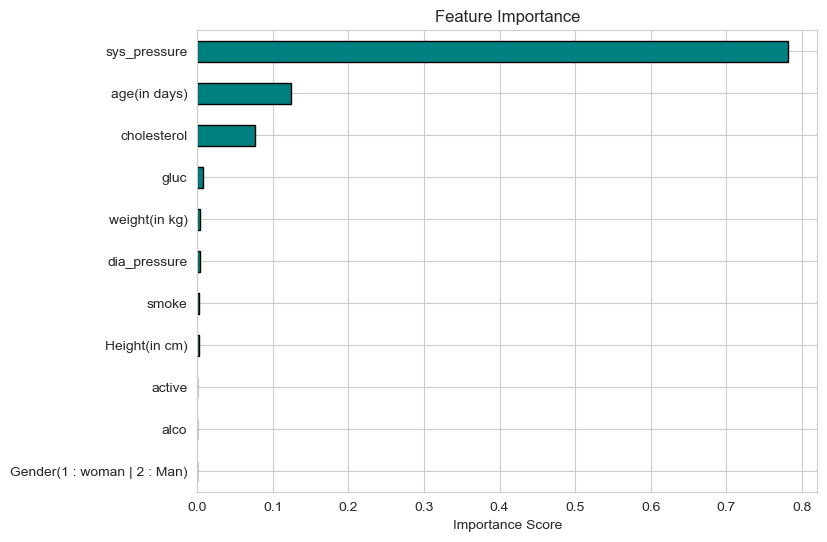

sys_pressure                   0.781211
age(in days)                   0.123802
cholesterol                    0.075801
gluc                           0.007412
weight(in kg)                  0.004110
dia_pressure                   0.003742
smoke                          0.002055
Height(in cm)                  0.001867
Gender(1 : woman | 2 : Man)    0.000000
alco                           0.000000
active                         0.000000
dtype: float64


In [77]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

print(importance.sort_values(ascending=False))

#### Systolic blood pressure (`sys_pressure`) dominates the model's decisions, followed by age and cholesterol. This matches real medical knowledge — high blood pressure is one of the strongest known risk factors for cardiovascular disease.

## Decision Tree Visualization

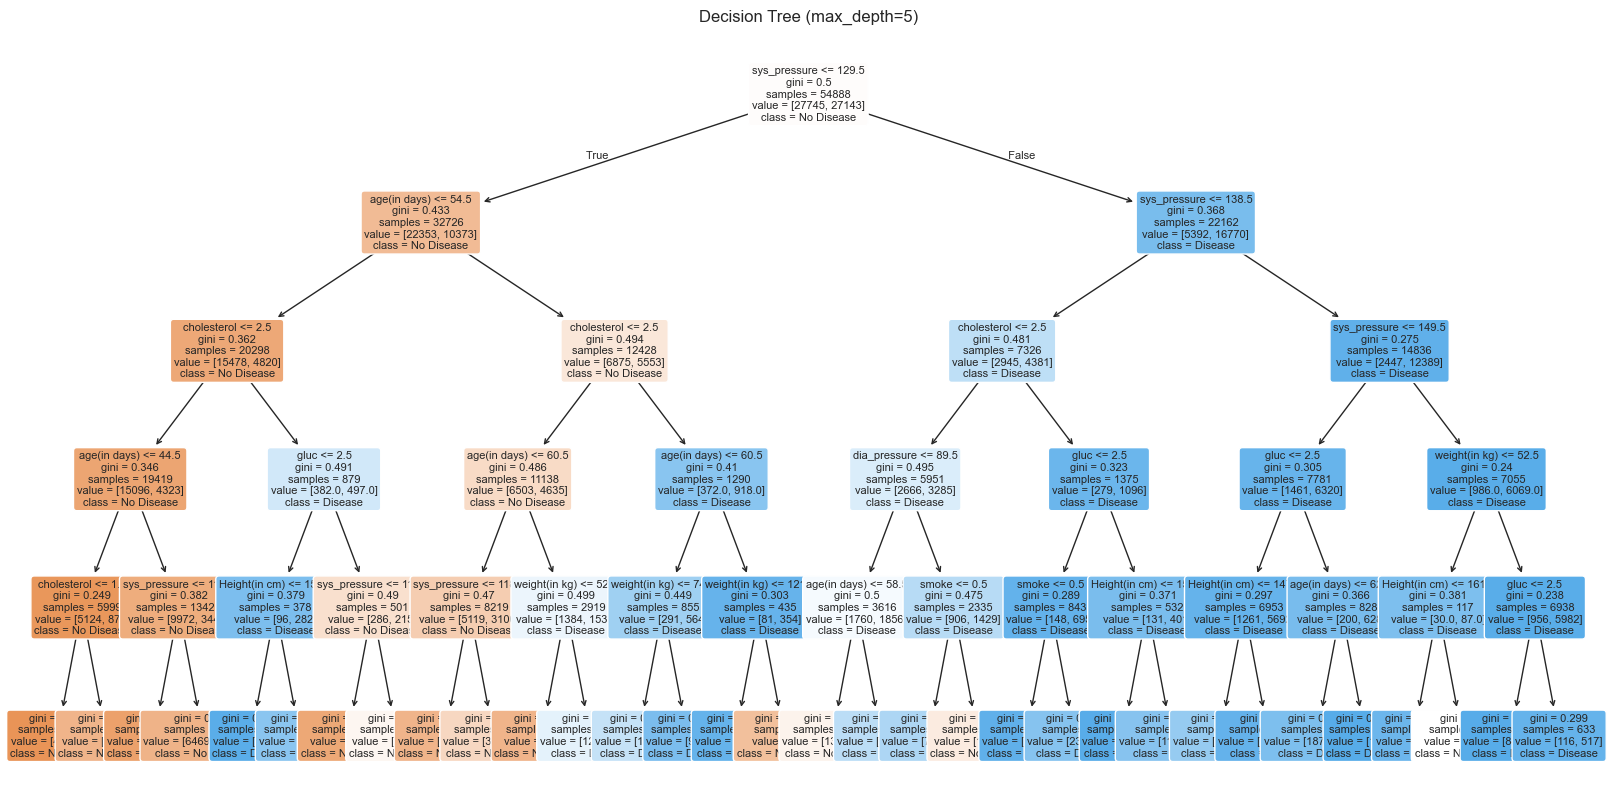

In [78]:
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (max_depth=5)')
plt.show()

## Demo Prediction
Testing the model on a single sample patient.

In [79]:
sample_patient = {
    'age(in days)': 55,
    'Gender(1 : woman | 2 : Man)': 1,
    'Height(in cm)': 165,
    'weight(in kg)': 78,
    'sys_pressure': 140,
    'dia_pressure': 90,
    'cholesterol': 2,
    'gluc': 1,
    'smoke': 0,
    'alco': 0,
    'active': 1
}

sample_df = pd.DataFrame([sample_patient])
prediction = model.predict(sample_df)[0]
probability = model.predict_proba(sample_df)[0]

print("Sample Patient:", sample_patient)
print(f"\nProbability of No Disease: {probability[0]*100:.1f}%")
print(f"Probability of Disease: {probability[1]*100:.1f}%")

if prediction == 1:
    print("\nPrediction: Cardiovascular Disease Detected")
else:
    print("\nPrediction: No Cardiovascular Disease Detected")

Sample Patient: {'age(in days)': 55, 'Gender(1 : woman | 2 : Man)': 1, 'Height(in cm)': 165, 'weight(in kg)': 78, 'sys_pressure': 140, 'dia_pressure': 90, 'cholesterol': 2, 'gluc': 1, 'smoke': 0, 'alco': 0, 'active': 1}

Probability of No Disease: 17.9%
Probability of Disease: 82.1%

Prediction: Cardiovascular Disease Detected
